In [1]:
import scanpy as sc
import seaborn as sns
import numpy as np
import pandas as pd

from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
ROOT = Path.cwd().parent
DATA_RAW = ROOT / "data/raw"
DATA_PP  = ROOT / "data/preprocessed"
RESULTS = ROOT / "results/old-subset"

In [7]:
# read data & compute umaps

adata = sc.read_h5ad(RESULTS / "annotated.h5ad")

sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pp.pca(adata, obsm='X_scenic_auc', key_added='X_pca_scenic')
sc.pp.neighbors(adata, use_rep='X_pca_scenic', key_added='neighbors_scenic')
sc.tl.umap(adata, neighbors_key='neighbors_scenic', key_added='X_umap_scenic')

/home/aspandit/lab/scenic/analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
adata, adata.obsm['X_scenic_auc'].shape

(AnnData object with n_obs × n_vars = 2600 × 4597
     obs: 'orig.identlf', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'nCount_CMO', 'nFeature_CMO', 'percent.mt', 'Population', 'Age', 'RNA_snn_res.0.8', 'seurat_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet', 'doublet_score', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'citeseq_annotation_L2_case2', 'citeseq_annotation_L2_case1', 'citeseq_annotation_L1', 'NK11', 'Sca1', 'protein_leiden', 'rna_leiden', 'F4-80', 'CX3CR1', 'joint_leiden', 'B220', 'CD127', 'CD4', 'CD11b', 'CD62P', 'MHCII', 'citeseq_annotation', 'CD117', 'CD63', 'CD54', 'CD9', 'CD11c', 'citeseq_annotation_L2', 'CD105', 'CD44', 'CD61', 'CD8a', 'CD150total_seq', 'CD27', 'Gr1', 'CD62L', 'CD79b', 'CD16-32', 'CD5', 'CD86', 'CD34', 'CD38', 'CD69', 'CD135', 'CD48', 'CD41', 'CD3', 'TER119', 'CD150_ADT', 'dpt_pseudotime', 'updated_cluster_assignment', 'updated_cluster_assignment_v3', 

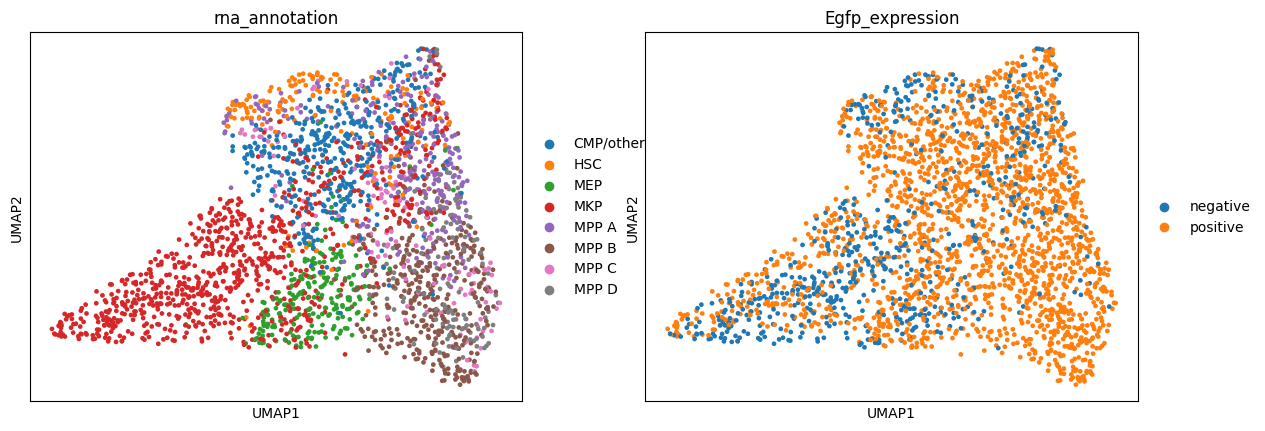

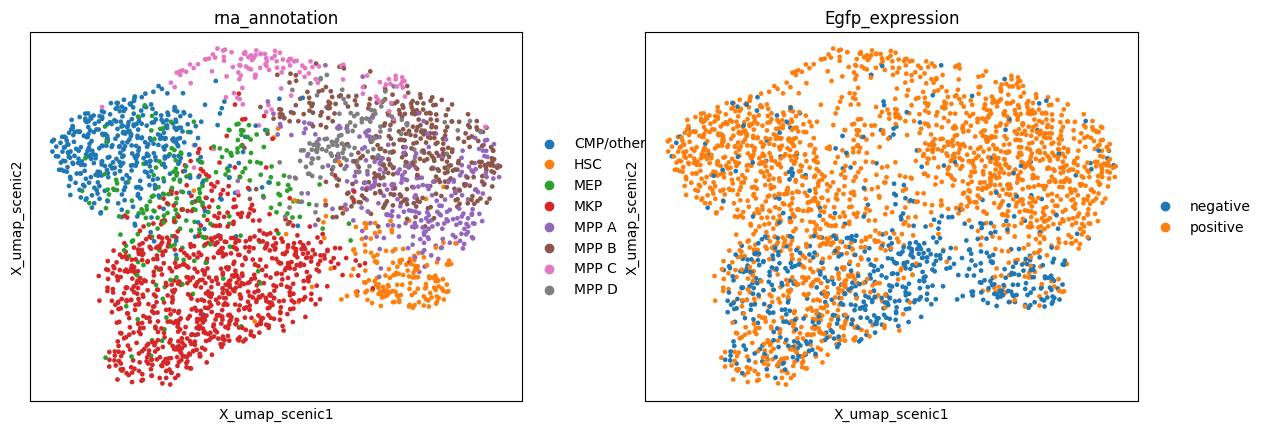

In [11]:
sc.pl.umap(adata, color=['rna_annotation', 'Egfp_expression'])
sc.pl.embedding(adata, basis='X_umap_scenic', color=['rna_annotation', 'Egfp_expression'])